In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Bereinigten Datensatz laden
df = pd.read_csv('../data/autoscout24_cleaned.csv')
print(f"Datensatz erfolgreich geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten.")

Datensatz erfolgreich geladen: 44107 Zeilen, 9 Spalten.


In [2]:
# 1. Die 5 häufigsten Hersteller identifizieren
top_5_makes = df['make'].value_counts().head(5).index.tolist()
print("Top 5 Hersteller nach Verkaufszahlen:", top_5_makes)

# 2. Datensatz auf diese 5 Hersteller filtern
df_top5 = df[df['make'].isin(top_5_makes)].copy()

# 3. Durchschnittlichen Verkaufspreis pro Hersteller berechnen
avg_prices = df_top5.groupby('make')['price'].mean().round(2)
print("\nDurchschnittlicher Verkaufspreis pro Hersteller (€):")
print(avg_prices)

Top 5 Hersteller nach Verkaufszahlen: ['Volkswagen', 'Opel', 'Ford', 'Skoda', 'Renault']

Durchschnittlicher Verkaufspreis pro Hersteller (€):
make
Ford          13749.94
Opel          10371.58
Renault       11246.68
Skoda         13661.54
Volkswagen    15962.33
Name: price, dtype: float64


In [3]:
# Features (X) und Zielvariable (y) festlegen
features = ['make', 'model', 'fuel', 'gear', 'mileage', 'hp', 'year']
target = 'price'

X = df_top5[features]
y = df_top5[target]

categorical_cols = ['make', 'model', 'fuel', 'gear']
numeric_cols = ['mileage', 'hp', 'year']

# Pipeline für One-Hot-Encoding & Skalierung
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Datensatz aufteilen (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Trainingsdaten: {X_train.shape[0]} Datensätze | Testdaten: {X_test.shape[0]} Datensätze")

Trainingsdaten: 16784 Datensätze | Testdaten: 4197 Datensätze


In [4]:
models = {
    'Linear Regression': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())]),
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
}

results = {}

for name, model in models.items():
    print(f"Trainiere Modell: {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Metriken berechnen
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE (€)': mae, 'RMSE (€)': rmse, 'R²-Score': r2}

# Zusammenfassung der Ergebnisse
df_results = pd.DataFrame(results).T
print("\n=== EVALUIERUNGSERGEBNISSE ===")
print(df_results.round(3))

Trainiere Modell: Linear Regression...
Trainiere Modell: Random Forest...

=== EVALUIERUNGSERGEBNISSE ===
                    MAE (€)  RMSE (€)  R²-Score
Linear Regression  2090.067  3295.258     0.884
Random Forest      1368.164  2384.824     0.939


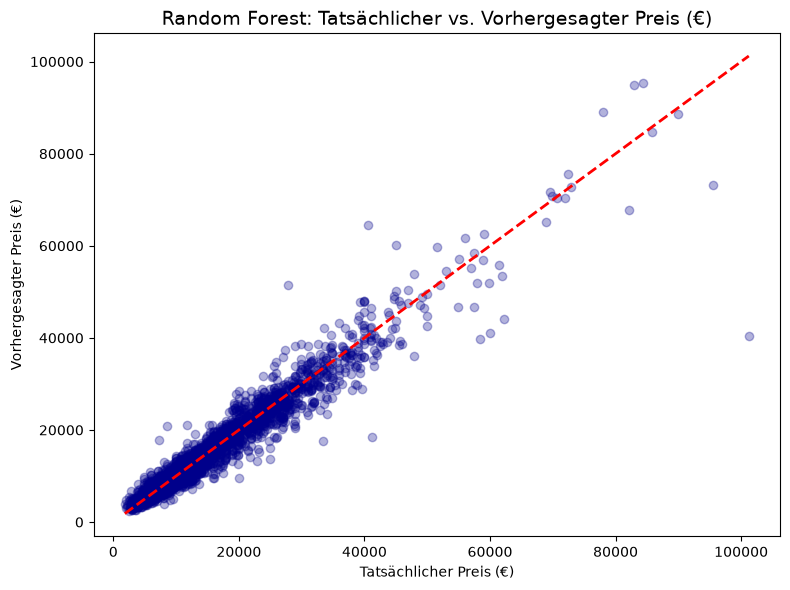

In [5]:
# Vorhersage des besten Modells (Random Forest) visualisieren
best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Random Forest: Tatsächlicher vs. Vorhergesagter Preis (€)", fontsize=14)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.tight_layout()
plt.show()